In [3]:
import pandas as pd
df = pd.read_csv("../data/cleaned_car_data.csv")
print(df.head())

   Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type Seller_Type  \
0  2014           3.35           5.59       27000    Petrol      Dealer   
1  2013           4.75           9.54       43000    Diesel      Dealer   
2  2017           7.25           9.85        6900    Petrol      Dealer   
3  2011           2.85           4.15        5200    Petrol      Dealer   
4  2014           4.60           6.87       42450    Diesel      Dealer   

  Transmission  Owner  
0       Manual      0  
1       Manual      0  
2       Manual      0  
3       Manual      0  
4       Manual      0  


In [4]:
current_year = 2026
df['Car_Age'] = current_year - df['Year']
print(df[['Year', 'Car_Age']].head())

   Year  Car_Age
0  2014       12
1  2013       13
2  2017        9
3  2011       15
4  2014       12


In [5]:
df['Mileage_per_Year'] = df['Kms_Driven'] / df['Car_Age']
print(df[['Kms_Driven', 'Car_Age', 'Mileage_per_Year']].head())

   Kms_Driven  Car_Age  Mileage_per_Year
0       27000       12       2250.000000
1       43000       13       3307.692308
2        6900        9        766.666667
3        5200       15        346.666667
4       42450       12       3537.500000


In [6]:
import numpy as np
df['Log_Selling_Price'] = np.log(df['Selling_Price'])
df['Log_Kms_Driven'] = np.log(df['Kms_Driven'])

In [7]:
bins = [0, 5, 10, 20]
labels = ['New', 'Medium', 'Old']
df['Age_Group'] = pd.cut(df['Car_Age'], bins=bins, labels=labels)
print(df[['Car_Age', 'Age_Group']].head())

   Car_Age Age_Group
0       12       Old
1       13       Old
2        9    Medium
3       15       Old
4       12       Old


In [8]:
df.to_csv("../data/engineered_car_data.csv", index=False)

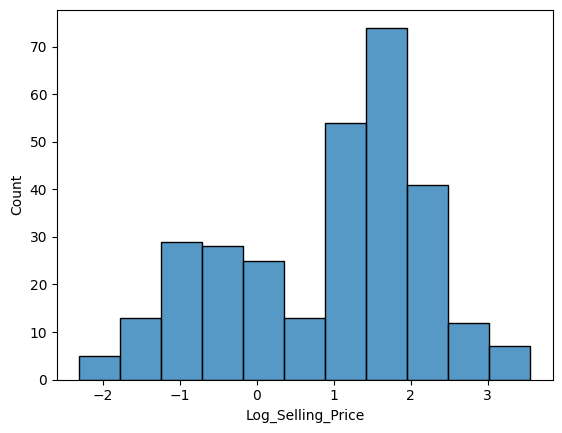

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df['Log_Selling_Price'])
plt.show()

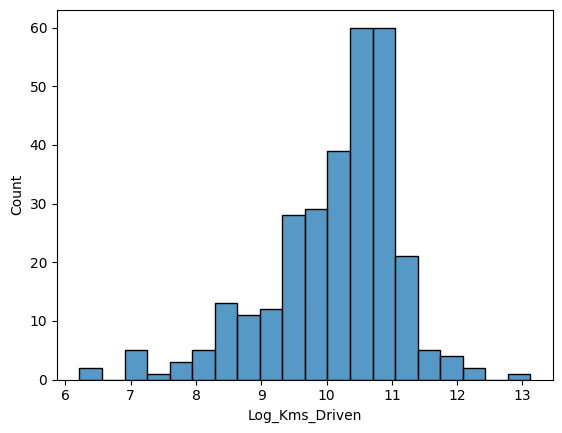

In [10]:
sns.histplot(df['Log_Kms_Driven'])
plt.show()

In [11]:
print(df.columns)

Index(['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type',
       'Seller_Type', 'Transmission', 'Owner', 'Car_Age', 'Mileage_per_Year',
       'Log_Selling_Price', 'Log_Kms_Driven', 'Age_Group'],
      dtype='str')


In [12]:
df = pd.get_dummies(
    df,
    columns=['Fuel_Type', 'Seller_Type', 'Transmission', 'Age_Group'],
    drop_first=True
)

print(df.head())

   Year  Selling_Price  Present_Price  Kms_Driven  Owner  Car_Age  \
0  2014           3.35           5.59       27000      0       12   
1  2013           4.75           9.54       43000      0       13   
2  2017           7.25           9.85        6900      0        9   
3  2011           2.85           4.15        5200      0       15   
4  2014           4.60           6.87       42450      0       12   

   Mileage_per_Year  Log_Selling_Price  Log_Kms_Driven  Fuel_Type_Diesel  \
0       2250.000000           1.208960       10.203592             False   
1       3307.692308           1.558145       10.668955              True   
2        766.666667           1.981001        8.839277             False   
3        346.666667           1.047319        8.556414             False   
4       3537.500000           1.526056       10.656082              True   

   Fuel_Type_Petrol  Seller_Type_Individual  Transmission_Manual  \
0              True                   False                 

In [21]:
df['Fuel_Transmission'] = (
    df['Fuel_Type_Petrol'].astype(str)
    + "_"
    + df['Transmission_Manual'].astype(str)
)

print(df[['Fuel_Transmission']].head())

  Fuel_Transmission
0         True_True
1        False_True
2         True_True
3         True_True
4        False_True


In [22]:
df = pd.get_dummies(df, columns=['Fuel_Transmission'], drop_first=True)
print(df.head())

   Year  Selling_Price  Present_Price  Kms_Driven  Owner  Car_Age  \
0  2014           3.35           5.59       27000      0       12   
1  2013           4.75           9.54       43000      0       13   
2  2017           7.25           9.85        6900      0        9   
3  2011           2.85           4.15        5200      0       15   
4  2014           4.60           6.87       42450      0       12   

   Mileage_per_Year  Log_Selling_Price  Log_Kms_Driven  Fuel_Type_Diesel  ...  \
0       2250.000000           1.208960       10.203592             False  ...   
1       3307.692308           1.558145       10.668955              True  ...   
2        766.666667           1.981001        8.839277             False  ...   
3        346.666667           1.047319        8.556414             False  ...   
4       3537.500000           1.526056       10.656082              True  ...   

   Transmission_Manual  Age_Group_Medium  Age_Group_Old  \
0                 True             Fals

In [23]:
df['Depreciation'] = (
    df['Present_Price'] - df['Selling_Price']
)

print(df[['Present_Price', 'Selling_Price', 'Depreciation']].head())

   Present_Price  Selling_Price  Depreciation
0           5.59           3.35          2.24
1           9.54           4.75          4.79
2           9.85           7.25          2.60
3           4.15           2.85          1.30
4           6.87           4.60          2.27


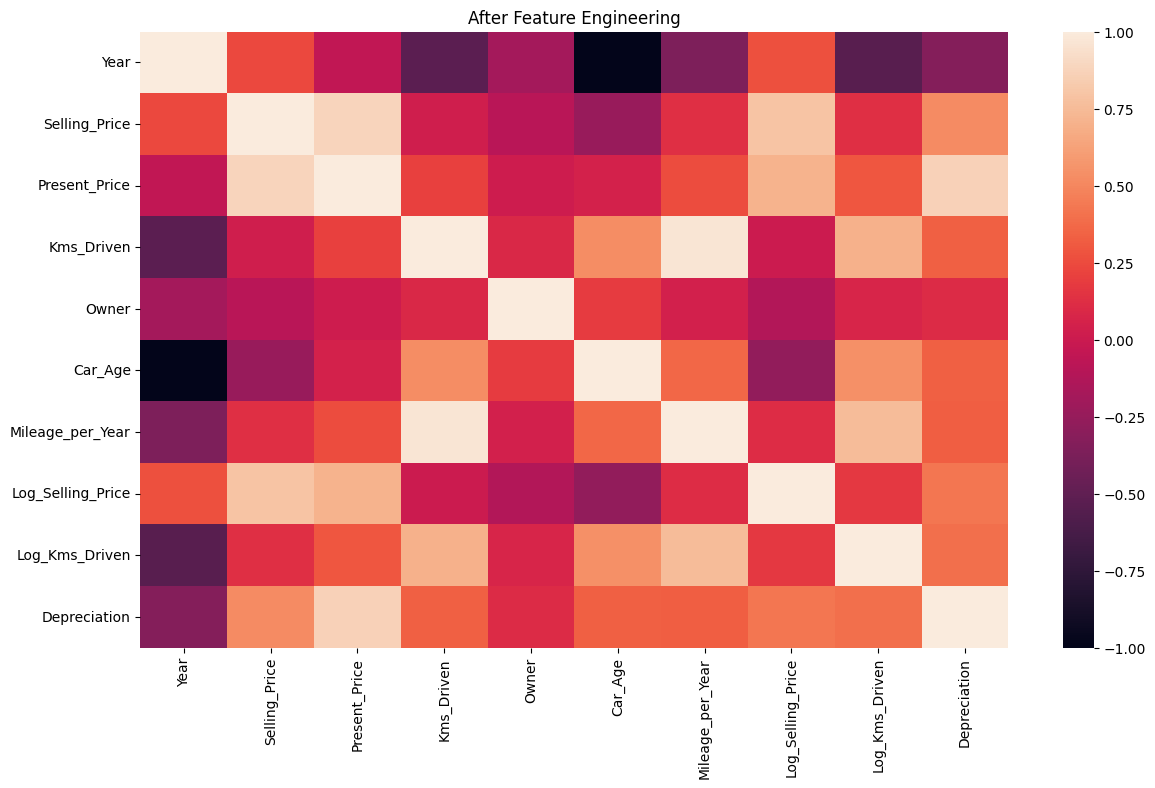

In [24]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(14,8))

sns.heatmap(numeric_df.corr(), annot=False)

plt.title("After Feature Engineering")

plt.show()

In [28]:
df['Depreciation'] = (
    df['Present_Price'] - df['Selling_Price']
)

print(df[['Present_Price', 'Selling_Price', 'Depreciation']].head())

   Present_Price  Selling_Price  Depreciation
0           5.59           3.35          2.24
1           9.54           4.75          4.79
2           9.85           7.25          2.60
3           4.15           2.85          1.30
4           6.87           4.60          2.27


In [29]:
X= df.drop('Selling_Price', axis=1)

y = df['Selling_Price']

print(X.shape)

print(y.shape)

(301, 21)
(301,)


In [30]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_numeric = X.select_dtypes(include=['number'])

vif_data = pd.DataFrame()

vif_data["Feature"] = X_numeric.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_numeric.values, i)
    for i in range(len(X_numeric.columns))
]

print(vif_data)

             Feature         VIF
0               Year  248.776970
1      Present_Price    9.560646
2         Kms_Driven   47.274851
3              Owner    1.064809
4            Car_Age  110.567960
5   Mileage_per_Year   53.572605
6  Log_Selling_Price    3.075441
7     Log_Kms_Driven    5.857335
8       Depreciation    7.025742


In [34]:
from sklearn.feature_selection import mutual_info_regression
mi = mutual_info_regression(X_numeric, y)

mi_df = pd.DataFrame({
    'Feature': X_numeric.columns,
    'MI Score': mi
})

print(mi_df.sort_values(by='MI Score', ascending=False))

             Feature  MI Score
6  Log_Selling_Price  3.744613
1      Present_Price  1.296957
8       Depreciation  0.755130
4            Car_Age  0.269030
0               Year  0.263531
2         Kms_Driven  0.163388
7     Log_Kms_Driven  0.132517
5   Mileage_per_Year  0.105723
3              Owner  0.004512


In [36]:
df.to_csv("../data/final_engineered_data.csv", index=False)